# This the notebook with the model

Here will be the whole workflow with the model building

In [1]:
!pip install word2number
!pip install num2words
!pip install gensim

In [2]:
# load the google news 300 word2vec model
import gensim.downloader as api
w2v = api.load('word2vec-google-news-300') # loads for a couple of minutes

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# load the data
train_path = os.path.join( "train_listings.csv")
test_path = os.path.join( "test_listings.csv")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

#Preporcess the data

In [5]:
from data_prepocessing import full_preprocess
train_df = full_preprocess(train_df)
test_df = full_preprocess(test_df)

/content/data_prepocessing.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)
/content/data_prepocessing.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)
/content/data_prepocessing.py:43: SettingWithCopyWarn

In [6]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [7]:
# split the data into X and y
X_train = train_df.drop(columns=["price"])
y_train = train_df["price"]

X_test = test_df.drop(columns=["price"])
y_test = test_df["price"]

# normilize the numeric data

In [8]:
numerical_features = ["accommodates", "bedrooms", "beds", "bathrooms"]
X_num_train = X_train[numerical_features]
X_num_test = X_test[numerical_features]



In [9]:
# normilize using the MinMaxscaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_num_train = scaler.fit_transform(X_num_train) # fit scaler and trasform the data for train
X_num_train = pd.DataFrame(X_num_train, columns=numerical_features, index=X_train.index)

X_num_test = scaler.transform(X_num_test) # trasform the test data using the same scaler
X_num_test = pd.DataFrame(X_num_test, columns=numerical_features, index=X_test.index)

# update the original dataset
X_train[numerical_features] = X_num_train
X_test[numerical_features] = X_num_test

In [10]:
# normilize the prices
#scaler = MinMaxScaler()
#y_train = scaler.fit_transform(pd.DataFrame(y_train))

#y_test = scaler.transform(pd.DataFrame(y_test))


In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4767 entries, 0 to 5055
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   description                4767 non-null   object 
 1   accommodates               4767 non-null   float64
 2   bedrooms                   4767 non-null   float64
 3   beds                       4767 non-null   float64
 4   bathrooms                  4767 non-null   float64
 5   room_type_Entire home/apt  4767 non-null   bool   
 6   room_type_Hotel room       4767 non-null   bool   
 7   room_type_Private room     4767 non-null   bool   
 8   room_type_Shared room      4767 non-null   bool   
 9   Stove                      4767 non-null   bool   
 10  Shampoo                    4767 non-null   bool   
 11  Washer                     4767 non-null   bool   
 12  GoodView                   4767 non-null   bool   
 13  HotTub                     4767 non-null   bool   
 1

# Process the bool data
Convert to float64 for the upcomming transition to torch.tensor

In [12]:
X_train = X_train.astype({col: 'float64' for col in X_train.select_dtypes(include='bool').columns})
X_test = X_test.astype({col: 'float64' for col in X_test.select_dtypes(include='bool').columns})


# Transform the description data into numercs with word2vec

Use Word2vec to convert words into numbers


In [13]:
# this is from https://github.com/hansonchang2008/house-price-prediction-web-app
class MeanEmbeddingVectorizer(object):
    def __init__(self, word2vec):
        self.word2vec = word2vec
        # if a text is empty we should return a vector of zeros
        # with the same dimensionality as all the other vectors
        self.dim = word2vec.vector_size


    def fit(self, X, y):
        return self

    def transform(self, X):
        return np.array([np.mean([self.word2vec[w] for w in words if w in self.word2vec] or [np.zeros(self.dim)], axis=0) for words in X])

def word2vec(df):
    model=w2v
    w2v = dict(zip(model.wv.index2word, model.wv.syn0))
    MEV=MeanEmbeddingVectorizer(w2v)
    w2v_df=MEV.transform(df)
    return w2v_df

In [14]:
MEV=MeanEmbeddingVectorizer(w2v)

# transform the train data
X_text_train = X_train['description']
transformed_X_train=MEV.transform(X_text_train)
X_text_df_train = pd.DataFrame(transformed_X_train, index=X_train.index)

#transform the test data
X_text_test = X_test['description']
transformed_X_test=MEV.transform(X_text_test)
X_text_df_test = pd.DataFrame(transformed_X_test, index=X_test.index)

In [15]:
# combine the whole prepocessed data

X_train = pd.concat([X_train.drop(columns=["description"]), X_text_df_train], axis=1)

X_test = pd.concat([X_test.drop(columns=["description"]), X_text_df_test], axis=1)


In [16]:
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.ravel(y_train)


X_test = np.asarray(X_test).astype(np.float32)
y_test = np.ravel(y_test)

In [17]:
from sklearn.ensemble import GradientBoostingRegressor
reg = GradientBoostingRegressor(random_state=0)
reg.fit(X_train, y_train)

GradientBoostingRegressor(random_state=0)

In [18]:
print("regression score with gradient boosting: ", reg.score(X_test, y_test))

regression score with gradient boosting:  0.46436302854359734


# Create a Pytorch model

In [19]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

# set the seed for reproducibility
seed = 2025
np.random.seed(seed)
torch.manual_seed(seed)


In [20]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# create a validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train.reshape(-1,1), test_size=0.1)

# transform to tensors and create dataloaders
X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()

train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

X_val = torch.tensor(X_val).float()
y_val = torch.tensor(y_val).float()

val_dataset = TensorDataset(X_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).float()

test_dataset = TensorDataset(X_test, y_test.reshape(-1,1))
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)




Create a model

In [21]:
import torch.nn as nn
from tqdm import tqdm
class PricePredictor(nn.Module):
    def __init__(self, input_dim, neurons = 50, dropout_rate = 0):
        super(PricePredictor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, neurons),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(neurons, neurons**2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(neurons**2, neurons),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(neurons, neurons),
            nn.ReLU(),
            nn.Dropout(dropout_rate),


            nn.Linear(neurons, 1)
        )

    def forward(self, x):
        return self.net(x)

def train(dataloader, optimizer, model, loss_function, device):
    losses = []
    model.train()
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        #forward
        y_pred = model(x_batch)
        loss = loss_function(y_pred, y_batch)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return np.mean(losses)

def val(dataloader, model, loss_function, device):
    losses = []
    model.eval()
    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        with torch.no_grad():
            val_pred = model(x_batch)
            loss = loss_function(val_pred, y_batch).item()

        losses.append(loss)

    return np.mean(losses)

def run_training(model, optimizer, loss_function, train_dataloader, val_dataloader, num_epochs, device):
    train_losses = []
    val_losses = []
    for epoch in tqdm(range(num_epochs)):
        train_loss = train(train_dataloader, optimizer, model, loss_function, device)
        val_loss = val(val_dataloader, model, loss_function, device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
    return train_losses, val_losses

In [22]:
model = PricePredictor(input_dim=X_train.shape[1], neurons = 300 , dropout_rate= 0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
loss_function = nn.MSELoss()
epochs = 100
train_loss, val_loss = run_training(model, optimizer, loss_function, train_dataloader, val_dataloader, epochs, device)

100%|██████████| 100/100 [05:03<00:00,  3.04s/it]


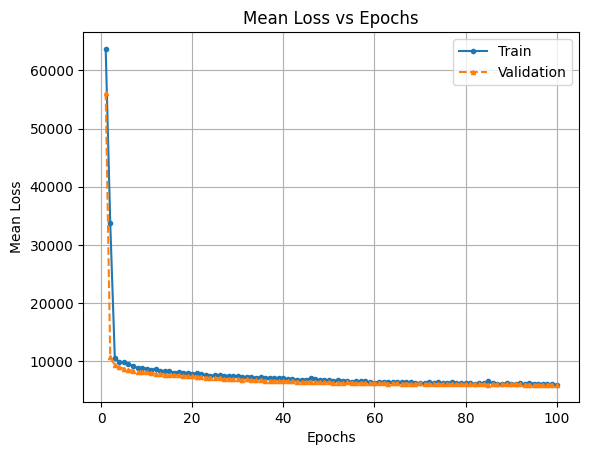

In [23]:
plt.plot(range(1, epochs + 1), train_loss, marker = "o", ms = 3)
plt.plot(range(1, epochs + 1), val_loss, marker = "^", ms = 3, ls = "--")
plt.xlabel("Epochs")
plt.ylabel("Mean Loss")
plt.legend(["Train", "Validation"])
plt.title("Mean Loss vs Epochs")
plt.grid()
plt.show()

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate model
model.eval()  # Set model to evaluation mode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Collect predictions
predictions = []
actuals = []

with torch.no_grad():  # Disable gradient computation for efficiency
    for xb, yb in test_dataloader:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model(xb).view(-1)  # Flattening outputs if necessary

        predictions.append(outputs.cpu().numpy())
        actuals.append(yb.cpu().numpy())

# Convert list of arrays into single arrays
predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# Compute metrics
mse = mean_squared_error(actuals, predictions)
r2 = r2_score(actuals, predictions)

print(f"Test MSE: {mse:.4f}")
print(f"Test R2 Score: {r2:.4f}")

Test MSE: 5573.0337
Test R2 Score: 0.4402


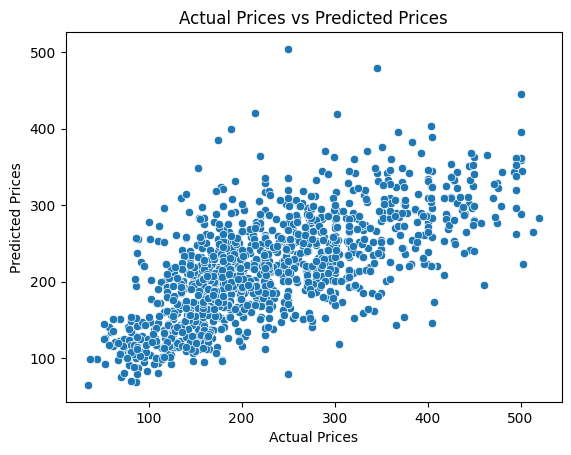

In [25]:
sns.scatterplot(x=actuals.reshape(-1), y=predictions.reshape(-1))
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()